In [12]:
from scipy.optimize import fsolve
import numpy as np
import matplotlib.pyplot as plt

## Parameters

F = 100
S0 = 10
Y_xs = 0.5
mu_max = 1
Ks = 0.75

# Volumes 

volumes = np.array([
    [800, 200],  # config a
    [200, 800],  # config b
    [900, 100],  # config c
    [100, 900]   # config d
])

# Lists for storing results
S2_results = []
X2_results = []

# Configurations labels
labels = ['a (800/200)', 'b (200/800)', 'c (900/100)', 'd (100/900)', 'Single (1000)']

for i, config in enumerate(volumes):
    V1, V2 = config

    # Reactor 1
    D1 = F / V1

    # wahsout
    if D1>=mu_max:
        S1 = S0
        X1 = 0
    else: 
        S1 = Ks*D1/(mu_max-D1)
        X1 = Y_xs*(S0-S1)

    # Reactor 2
    D2 = F / V2

    # fsolve for S2
    
    def equations_S2(S2):
        return D2*(S2-S1) + (mu_max*S2/(Ks+S2))*(S0-S2)
    
    S2_solution = fsolve(equations_S2, 0.1)[0]

    # fsolve for X2

    X2_solution = Y_xs*(S0-S2_solution)

    # Store results
    S2_results.append(S2_solution)
    X2_results.append(X2_solution)

    print(f"Config {labels[i]}: Sortie S2 = {S2_solution:.3f} g/L | Sortie X2 = {X2_solution:.3f} g/L")

# single reactor of 1000 L 

D_single = F / 1000
if D_single>=mu_max:
    S_single = S0
    X_single = 0
else:
    S_single = Ks*D_single/(mu_max-D_single)
    X_single = Y_xs*(S0-S_single)

# Store results
    S2_results.append(S_single)
    X2_results.append(X_single)

print(f"Single Reactor (1000 L): Sortie S = {S_single:.3f} g/L | Sortie X = {X_single:.3f} g/L")
    

Config a (800/200): Sortie S2 = 0.004 g/L | Sortie X2 = 4.998 g/L
Config b (200/800): Sortie S2 = 0.007 g/L | Sortie X2 = 4.996 g/L
Config c (900/100): Sortie S2 = 0.007 g/L | Sortie X2 = 4.997 g/L
Config d (100/900): Sortie S2 = 0.094 g/L | Sortie X2 = 4.953 g/L
Single Reactor (1000 L): Sortie S = 0.083 g/L | Sortie X = 4.958 g/L


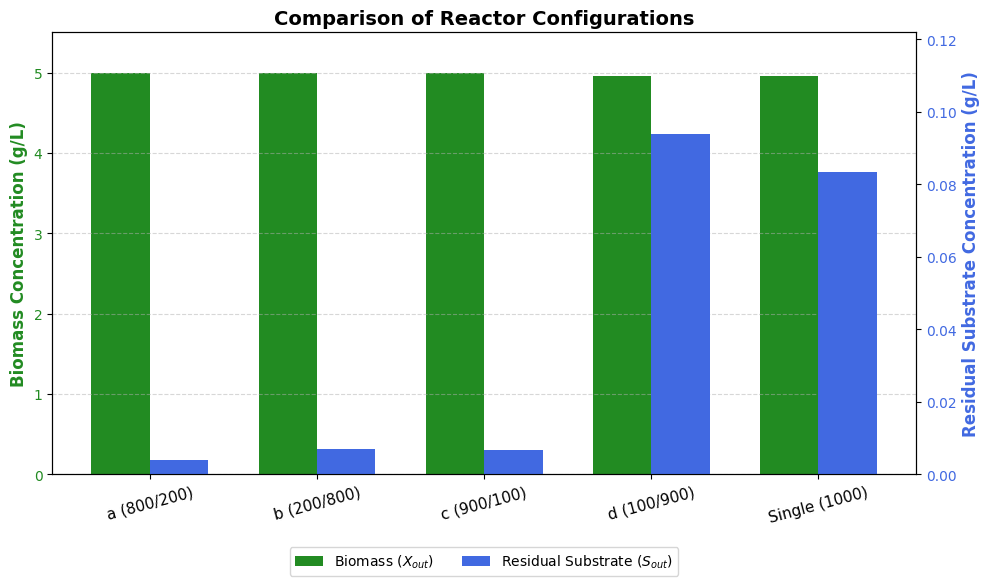

In [13]:
# --- PLOTTING ---
# x will now automatically create 5 positions since len(labels) == 5
x = np.arange(len(labels))
width = 0.35  # Width of the bars

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bars for Biomass (Left Y-axis)
bars1 = ax1.bar(x - width/2, X2_results, width, label='Biomass ($X_{out}$)', color='forestgreen')
ax1.set_ylabel('Biomass Concentration (g/L)', color='forestgreen', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='forestgreen')
ax1.set_ylim(0, 5.5) # Scale from 0 to 5.5 to comfortably fit the ~5g/L values

# Create a second Y-axis for Substrate (Right Y-axis)
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, S2_results, width, label='Residual Substrate ($S_{out}$)', color='royalblue')
ax2.set_ylabel('Residual Substrate Concentration (g/L)', color='royalblue', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='royalblue')
# Dynamic upper limit for substrate to see small differences better
ax2.set_ylim(0, max(S2_results) * 1.3)

# General aesthetics
ax1.set_title('Comparison of Reactor Configurations', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
# Added a slight rotation to accommodate the longer "Single Reactor" text
ax1.set_xticklabels(labels, fontsize=11, rotation=15) 
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Combined Legend for both axes
lines, labels_leg = ax1.get_legend_handles_labels()
lines2, labels_leg2 = ax2.get_legend_handles_labels()
# Moved legend slightly lower (-0.15) to avoid overlapping with tilted text
ax2.legend(lines + lines2, labels_leg + labels_leg2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

# Adjust layout to prevent cutting off labels
plt.tight_layout()

# Display the plot
plt.show()